# 🧹 Depuración de Dataset: Data Metrics

Este notebook realiza la limpieza y depuración del archivo `2_Data_Metrics.csv`.

**Problemas identificados:**
- Columna `sessionsWithMetricPercentage` tiene tipo mixto (string con valores como `'0.0x'`)
- Alto porcentaje de nulos en múltiples columnas
- Columnas casi completamente vacías (`averageScrollDepth`, `totalTime`, `activeTime`, etc.)
- Posibles duplicados

---

## 📦 1. Instalación e importación de librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Para Colab: si el archivo está en Drive, montarlo
# from google.colab import drive
# drive.mount('/content/drive')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 📂 2. Carga del dataset

In [4]:
# Ajusta la ruta según donde tengas el archivo
# En Colab puedes subir el archivo directamente o cargarlo desde Drive

FILE_PATH = '2_Data_Metrics.csv'  # Cambia esta ruta si es necesario

df_raw = pd.read_csv(FILE_PATH, low_memory=False)

print(f'✅ Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
df_raw.head()

✅ Dataset cargado: 33,741 filas × 16 columnas


,sessionsCount,sessionsWithMetricPercentage,sessionsWithoutMetricPercentage,pagesViews,subTotal,Url,Device,OS,metricName,averageScrollDepth,totalSessionCount,totalBotSessionCount,distinctUserCount,pagesPerSessionPercentage,totalTime,activeTime
0,1.0,0.0x,100.00,0.0,0.0,https://cloudlabslearning.com/request-demo?err...,Mobile,Android,DeadClickCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,0.0,100.00,0.0,0.0,https://cloudlabslearning.com/?utm_term=simula...,Mobile,Android,DeadClickCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,33.33,66.67,2.0,3.0,https://cloudlabslearning.com/elementary-schoo...,PC,Linux,DeadClickCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,0.0,100.00,0.0,0.0,https://cloudlabslearning.com/page-not-found,Mobile,Android,DeadClickCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,0.0,100.00,0.0,0.0,https://cloudlabslearning.com/downloads#error=...,Mobile,Android,DeadClickCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 🔍 3. Diagnóstico inicial

In [5]:
print('=== TIPOS DE DATOS ===')
print(df_raw.dtypes)
print()
print('=== DESCRIPCIÓN ESTADÍSTICA ===')
df_raw.describe(include='all')

=== TIPOS DE DATOS ===
sessionsCount                      float64
sessionsWithMetricPercentage        object
sessionsWithoutMetricPercentage    float64
pagesViews                         float64
subTotal                           float64
Url                                 object
Device                              object
OS                                  object
metricName                          object
averageScrollDepth                 float64
totalSessionCount                  float64
totalBotSessionCount               float64
distinctUserCount                  float64
pagesPerSessionPercentage          float64
totalTime                          float64
activeTime                         float64
dtype: object

=== DESCRIPCIÓN ESTADÍSTICA ===


,sessionsCount,sessionsWithMetricPercentage,sessionsWithoutMetricPercentage,pagesViews,subTotal,Url,Device,OS,metricName,averageScrollDepth,totalSessionCount,totalBotSessionCount,distinctUserCount,pagesPerSessionPercentage,totalTime,activeTime
count,22440.000000,22440,22440.000000,22440.000000,22440.000000,33740,33741,33741,33741,3739.000000,3822.000000,3822.000000,3822.000000,3822.000000,3740.000000,3740.000000
unique,NaN,117,NaN,NaN,NaN,4927,5,8,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,0.0,NaN,NaN,NaN,https://cloudlabslearning.com/,Mobile,Android,Traffic,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21821,NaN,NaN,NaN,202,17622,13946,3822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.981283,NaN,98.034772,0.072549,0.169697,NaN,NaN,NaN,NaN,92.523538,2.465463,0.126635,2.455521,1.077068,53.323529,23.692513
std,24.148327,NaN,13.466990,1.226479,3.533720,NaN,NaN,NaN,NaN,14.947156,19.068417,1.159229,17.119222,0.306816,127.988378,44.208115
min,1.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,8.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,NaN,100.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,92.000000,1.000000,0.000000,1.000000,1.000000,6.000000,5.000000
50%,1.000000,NaN,100.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,98.000000,1.000000,0.000000,1.000000,1.000000,14.000000,11.000000
75%,1.000000,NaN,100.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,100.000000,1.000000,0.000000,1.000000,1.000000,38.000000,24.000000


=== VALORES NULOS POR COLUMNA ===
                                 Nulos  % Nulos
activeTime                       30001    88.92
totalTime                        30001    88.92
averageScrollDepth               30002    88.92
totalSessionCount                29919    88.67
totalBotSessionCount             29919    88.67
distinctUserCount                29919    88.67
pagesPerSessionPercentage        29919    88.67
sessionsCount                    11301    33.49
pagesViews                       11301    33.49
sessionsWithoutMetricPercentage  11301    33.49
sessionsWithMetricPercentage     11301    33.49
subTotal                         11301    33.49
OS                                   0     0.00
Device                               0     0.00
Url                                  1     0.00
metricName                           0     0.00


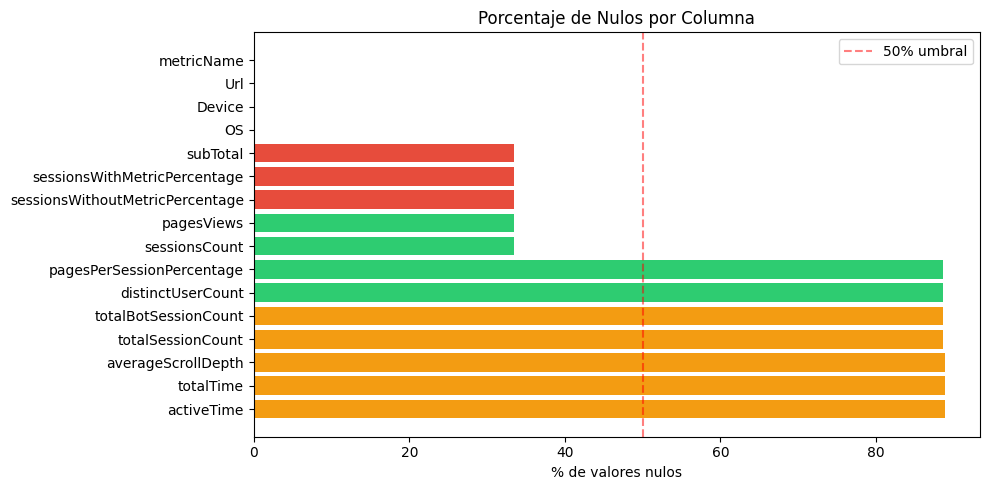

In [6]:
# Análisis de valores nulos
nulos = df_raw.isnull().sum()
pct_nulos = (nulos / len(df_raw) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    '% Nulos': pct_nulos
}).sort_values('% Nulos', ascending=False)

print('=== VALORES NULOS POR COLUMNA ===')
print(resumen_nulos)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if p > 50 else '#f39c12' if p > 10 else '#2ecc71' for p in pct_nulos]
ax.barh(resumen_nulos.index, resumen_nulos['% Nulos'], color=colors)
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% umbral')
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de Nulos por Columna')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Diagnóstico específico: columna con tipo mixto
print('=== COLUMNA PROBLEMÁTICA: sessionsWithMetricPercentage ===')
col = 'sessionsWithMetricPercentage'
print(f'Tipo actual: {df_raw[col].dtype}')
print(f'Valores únicos con caracteres no numéricos:')
valores_sucios = df_raw[col].dropna().astype(str)
no_numericos = valores_sucios[valores_sucios.str.contains(r'[^0-9.\-]', regex=True)]
print(no_numericos.value_counts())

=== COLUMNA PROBLEMÁTICA: sessionsWithMetricPercentage ===
Tipo actual: object
Valores únicos con caracteres no numéricos:
sessionsWithMetricPercentage
0.0x    1
Name: count, dtype: int64


In [8]:
# Duplicados
n_duplicados = df_raw.duplicated().sum()
print(f'=== DUPLICADOS ===')
print(f'Filas duplicadas: {n_duplicados} ({n_duplicados/len(df_raw)*100:.2f}%)')

# Distribución de columnas categóricas
print()
for col in ['Device', 'OS', 'metricName']:
    print(f'--- {col} ---')
    print(df_raw[col].value_counts())
    print()

=== DUPLICADOS ===
Filas duplicadas: 308 (0.91%)

--- Device ---
Device
Mobile    17622
PC        15208
Tablet      891
Other        12
Email         8
Name: count, dtype: int64

--- OS ---
OS
Android     13946
Windows     13628
IOS          4556
Linux         598
MacOSX        501
ChromeOS      465
Ubuntu         41
Other           6
Name: count, dtype: int64

--- metricName ---
metricName
Traffic             3822
DeadClickCount      3740
ExcessiveScroll     3740
QuickbackClick      3740
RageClickCount      3740
ScriptErrorCount    3740
ErrorClickCount     3740
EngagementTime      3740
ScrollDepth         3739
Name: count, dtype: int64



## 🧹 4. Limpieza y depuración

In [9]:
# Trabajamos sobre una copia para preservar el original
df = df_raw.copy()
print(f'Tamaño inicial: {df.shape}')

Tamaño inicial: (33741, 16)


In [10]:
# PASO 4.1 — Eliminar columnas con más del 80% de nulos
UMBRAL_NULOS = 80  # Porcentaje mínimo para eliminar columna

cols_a_eliminar = pct_nulos[pct_nulos > UMBRAL_NULOS].index.tolist()
print(f'Columnas a eliminar (> {UMBRAL_NULOS}% nulos): {cols_a_eliminar}')

df.drop(columns=cols_a_eliminar, inplace=True)
print(f'Tamaño después de eliminar columnas: {df.shape}')

Columnas a eliminar (> 80% nulos): ['averageScrollDepth', 'totalSessionCount', 'totalBotSessionCount', 'distinctUserCount', 'pagesPerSessionPercentage', 'totalTime', 'activeTime']
Tamaño después de eliminar columnas: (33741, 9)


In [11]:
# PASO 4.2 — Limpiar columna 'sessionsWithMetricPercentage'
# Eliminar caracteres no numéricos (ej: '0.0x' → '0.0') y convertir a float

if 'sessionsWithMetricPercentage' in df.columns:
    df['sessionsWithMetricPercentage'] = (
        df['sessionsWithMetricPercentage']
        .astype(str)
        .str.replace(r'[^0-9.\-]', '', regex=True)  # Quita todo excepto dígitos, punto y guion
        .replace('', np.nan)
        .astype(float)
    )
    print('✅ sessionsWithMetricPercentage convertida a float')
    print(df['sessionsWithMetricPercentage'].describe())

✅ sessionsWithMetricPercentage convertida a float
count    22440.000000
mean         1.965228
std         13.466990
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        100.000000
Name: sessionsWithMetricPercentage, dtype: float64


In [12]:
# PASO 4.3 — Eliminar filas duplicadas
antes = len(df)
df.drop_duplicates(inplace=True)
despues = len(df)

print(f'✅ Duplicados eliminados: {antes - despues} filas')
print(f'Tamaño actual: {df.shape}')

✅ Duplicados eliminados: 773 filas
Tamaño actual: (32968, 9)


In [13]:
# PASO 4.4 — Eliminar filas donde las columnas clave son todas nulas
# Columnas clave del negocio
COLS_CLAVE = ['sessionsCount', 'pagesViews', 'Url', 'metricName']
cols_clave_existentes = [c for c in COLS_CLAVE if c in df.columns]

antes = len(df)
df.dropna(subset=cols_clave_existentes, how='all', inplace=True)
despues = len(df)

print(f'✅ Filas eliminadas (todas las columnas clave nulas): {antes - despues}')
print(f'Tamaño actual: {df.shape}')

✅ Filas eliminadas (todas las columnas clave nulas): 0
Tamaño actual: (32968, 9)


In [14]:
# PASO 4.5 — Limpiar columna URL (eliminar espacios, normalizar a minúsculas)
if 'Url' in df.columns:
    df['Url'] = df['Url'].astype(str).str.strip().str.lower()
    df['Url'] = df['Url'].replace('nan', np.nan)
    print('✅ Columna Url limpiada')
    print(f'Nulos en Url: {df["Url"].isnull().sum()}')

✅ Columna Url limpiada
Nulos en Url: 1


In [15]:
# PASO 4.6 — Validar rangos de columnas de porcentaje (deben estar entre 0 y 100)
cols_porcentaje = [c for c in df.columns if 'percentage' in c.lower() or 'Percentage' in c]

for col in cols_porcentaje:
    if col in df.columns:
        fuera_rango = ((df[col] < 0) | (df[col] > 100)).sum()
        if fuera_rango > 0:
            print(f'⚠️  {col}: {fuera_rango} valores fuera del rango [0, 100] → se convierten a NaN')
            df.loc[(df[col] < 0) | (df[col] > 100), col] = np.nan
        else:
            print(f'✅ {col}: sin valores fuera de rango')

✅ sessionsWithMetricPercentage: sin valores fuera de rango
✅ sessionsWithoutMetricPercentage: sin valores fuera de rango


In [16]:
# PASO 4.7 — Estandarizar columnas categóricas (strip + title case)
cols_categoricas = ['Device', 'OS', 'metricName']

for col in cols_categoricas:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        print(f'✅ {col} estandarizada | Valores únicos: {df[col].nunique()}')

✅ Device estandarizada | Valores únicos: 5
✅ OS estandarizada | Valores únicos: 8
✅ metricName estandarizada | Valores únicos: 9


In [17]:
# PASO 4.8 — Resetear el índice
df.reset_index(drop=True, inplace=True)
print(f'✅ Índice reseteado. Dataset limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas')

✅ Índice reseteado. Dataset limpio: 32,968 filas × 9 columnas


## 📊 5. Reporte final de calidad

In [18]:
print('=========================================')
print('       REPORTE DE DEPURACIÓN FINAL       ')
print('=========================================')
print(f'Filas originales:  {df_raw.shape[0]:>10,}')
print(f'Filas finales:     {df.shape[0]:>10,}')
print(f'Filas eliminadas:  {df_raw.shape[0] - df.shape[0]:>10,}')
print(f'Columnas orig.:    {df_raw.shape[1]:>10}')
print(f'Columnas finales:  {df.shape[1]:>10}')
print()
print('--- Nulos restantes ---')
nulos_finales = df.isnull().sum()
print(nulos_finales[nulos_finales > 0])
print()
print('--- Tipos de datos finales ---')
print(df.dtypes)

       REPORTE DE DEPURACIÓN FINAL       
Filas originales:      33,741
Filas finales:         32,968
Filas eliminadas:         773
Columnas orig.:            16
Columnas finales:           9

--- Nulos restantes ---
sessionsCount                      10786
sessionsWithMetricPercentage       10786
sessionsWithoutMetricPercentage    10786
pagesViews                         10786
subTotal                           10786
Url                                    1
dtype: int64

--- Tipos de datos finales ---
sessionsCount                      float64
sessionsWithMetricPercentage       float64
sessionsWithoutMetricPercentage    float64
pagesViews                         float64
subTotal                           float64
Url                                 object
Device                              object
OS                                  object
metricName                          object
dtype: object


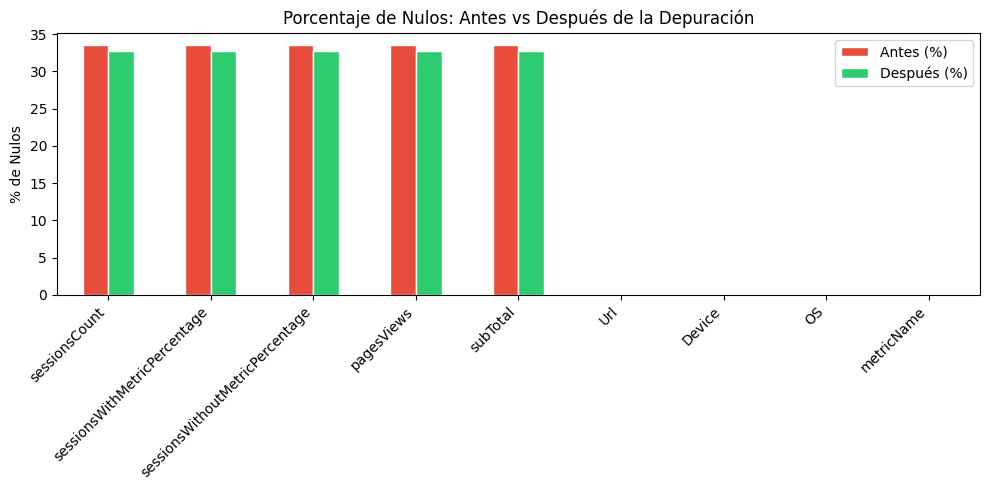

In [19]:
# Comparativa de nulos antes vs después
nulos_antes = df_raw[df.columns].isnull().mean() * 100
nulos_despues = df.isnull().mean() * 100

comparativa = pd.DataFrame({'Antes (%)': nulos_antes, 'Después (%)': nulos_despues})

fig, ax = plt.subplots(figsize=(10, 5))
comparativa.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white')
ax.set_title('Porcentaje de Nulos: Antes vs Después de la Depuración')
ax.set_ylabel('% de Nulos')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
print('=== VISTA PREVIA DEL DATASET LIMPIO ===')
df.head(10)

=== VISTA PREVIA DEL DATASET LIMPIO ===


,sessionsCount,sessionsWithMetricPercentage,sessionsWithoutMetricPercentage,pagesViews,subTotal,Url,Device,OS,metricName
0,1.0,0.00,100.00,0.0,0.0,https://cloudlabslearning.com/request-demo?err...,Mobile,Android,DeadClickCount
1,1.0,0.00,100.00,0.0,0.0,https://cloudlabslearning.com/?utm_term=simula...,Mobile,Android,DeadClickCount
2,3.0,33.33,66.67,2.0,3.0,https://cloudlabslearning.com/elementary-schoo...,PC,Linux,DeadClickCount
3,1.0,0.00,100.00,0.0,0.0,https://cloudlabslearning.com/page-not-found,Mobile,Android,DeadClickCount
4,1.0,0.00,100.00,0.0,0.0,https://cloudlabslearning.com/downloads#error=...,Mobile,Android,DeadClickCount
5,1.0,100.00,0.00,1.0,1.0,https://cloudlabslearning.com/#state=34ae480e-...,Mobile,IOS,DeadClickCount
6,1.0,0.00,100.00,0.0,0.0,https://cloudlabslearning.com/?utm_term=phet%2...,Mobile,Android,DeadClickCount
7,1.0,0.00,100.00,0.0,0.0,https://cloudlabslearning.com/uniminuto,PC,Windows,DeadClickCount
8,1.0,0.00,100.00,0.0,0.0,https://cloudlabslearning.com/?utm_term=gamifi...,Mobile,Android,DeadClickCount
9,1.0,0.00,100.00,0.0,0.0,https://cloudlabslearning.com/request-demo?err...,Mobile,Android,DeadClickCount


## 💾 6. Exportar dataset limpio

In [20]:
OUTPUT_PATH = '2_Data_Metrics_CLEAN.csv'

df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')
print(f'✅ Archivo guardado en: {OUTPUT_PATH}')

# Si estás en Colab, esto descargará el archivo automáticamente:
# from google.colab import files
# files.download(OUTPUT_PATH)

✅ Archivo guardado en: 2_Data_Metrics_CLEAN.csv
